# Fisher forecast: how precisely could Omega_m and sigma_8 be measured?

Every notebook so far reports whether a parameter's imprint on the
kNN-CDF is statistically significant. This notebook turns that into a
**precision forecast**: given how the kNN-CDF actually responds to
`Omega_m`/`sigma_8` (measured across the LH suite) and how much it
scatters at fixed parameters (measured from the CV set), how tight could
a joint `(Omega_m, sigma_8)` constraint be -- and how much does combining
AGN and galaxies narrow it, given notebook 06 found galaxies see a real
`sigma_8` signal AGN doesn't?

**This is not a predictor.** It doesn't take one measured kNN-CDF and
output point estimates of `Omega_m`/`sigma_8` for that specific
simulation -- that's a regression/emulator, a different tool (see the
README's roadmap). A Fisher forecast answers "how much information is in
this statistic, in principle", via a local-linear-response,
Gaussian-noise approximation. Two real simplifications go into every
number below, both explained where they're used:

1. Only the **diagonal** of the noise covariance is used (per-bin
   variance from the CV set), not the full bin-to-bin covariance -- the
   CV set has far too few realizations (~27-30) to invert a ~150-bin
   empirical covariance matrix. Neighbouring radial bins of a CDF are
   genuinely correlated, usually positively, so this likely
   **understates** the true uncertainty.
2. The "combined" AGN+galaxy forecast sums their Fisher matrices, which
   is only valid for *independent* data. Notebook 06 measured AGN and
   galaxy clustering fluctuations at median correlation 0.69 across the
   LH suite -- not independent -- so the combined forecast here is a
   **best-case upper bound** on how much combining helps, not a
   rigorous joint constraint (that needs the AGN-galaxy cross-covariance,
   which isn't built here).

Read every number as "at best, under these simplifications" -- directionally
informative, not a publication-grade forecast.


In [1]:
import sys
sys.path.insert(0, "..")

import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data_io import find_group_catalogs
from src.pipeline import run_galaxy_suite
from src.params import load_params, align_to_params
from src.cv import per_bin_std
from src.sensitivity import infer_layout
from src.fisher import (
    linear_response, fisher_matrix, combine_fisher,
    marginalized_covariance, sub_covariance, confidence_ellipse_params,
    drop_uninformative_bins,
)
from src.plotting import plot_fisher_ellipse

OUTPUT_DIR = config.OUTPUT_DIR


## 1. The missing ingredient: a galaxy noise floor

Notebook 05 ran the *AGN* pipeline over the CV set to get AGN's noise
floor. Nothing has run the *galaxy* pipeline over CV yet -- without it,
there's no covariance to build a galaxy Fisher matrix from at all. This
section generates that run.

`GROUPS_PATH_CV` (`src/config.py`) is inferred from the LH pattern
notebook 06 confirmed (`GROUPS_PATH = SIM_PATH`, no separate "Groups"
data type for this account) -- not independently checked for the CV set
specifically, so this discovers what's actually there first.


In [2]:
files_gal_cv = find_group_catalogs(config.GROUPS_PATH_CV, config.SNAP, prefix="CV_")
print(f"Found {len(files_gal_cv)} CV group catalogs at snap={config.SNAP}")

if not files_gal_cv:
    print(
        f"\nNo CV group catalogs found under {config.GROUPS_PATH_CV} -- check "
        "config.GROUPS_PATH_CV against where the CV set's group catalogs "
        "actually live for this account before continuing."
    )


Found 27 CV group catalogs at snap=50


## 2. Generate the galaxy CV run

Reads `N_TARGET_GAL` from notebook 06's saved LH run, the same
locked-to-the-upstream-run pattern every comparison notebook here uses,
so this can't silently drift onto a different N.


In [3]:
galaxy_candidates = sorted(glob.glob(f"{OUTPUT_DIR}/galaxy_knn_snap{config.SNAP}_M{config.GALAXY_MASS_CUT:.0e}_n*.npz"))
assert galaxy_candidates, f"No galaxy fixed-N run found in {OUTPUT_DIR} -- run notebook 06 first."
galaxy_data = np.load(galaxy_candidates[-1], allow_pickle=True)

N_TARGET_GAL = int(galaxy_data["nbh"][0])
assert np.all(galaxy_data["nbh"] == N_TARGET_GAL), "galaxy LH run is not fixed-N -- wrong file?"
print(f"N_TARGET_GAL = {N_TARGET_GAL} (from notebook 06's run)")


N_TARGET_GAL = 262 (from notebook 06's run)


In [4]:
GENERATE = True

galaxy_cv_path = f"{OUTPUT_DIR}/galaxy_cv_knn_snap{config.SNAP}_M{config.GALAXY_MASS_CUT:.0e}_n{N_TARGET_GAL}.npz"

if GENERATE:
    result_gal_cv = run_galaxy_suite(
        n_target=N_TARGET_GAL, groups_path=config.GROUPS_PATH_CV,
        dir_prefix="CV_", output_dir=OUTPUT_DIR,
    )
else:
    data = np.load(galaxy_cv_path, allow_pickle=True)
    result_gal_cv = {k: data[k] for k in ("sim_ids", "summaries", "nbh", "rgrid", "kvals")}

gal_cv_sim_ids = result_gal_cv["sim_ids"]
gal_cv_summaries = result_gal_cv["summaries"]
gal_cv_rgrid = result_gal_cv["rgrid"]
gal_cv_kvals = result_gal_cv["kvals"]
gal_cv_n_k, gal_cv_n_r = infer_layout(gal_cv_kvals, gal_cv_rgrid)

assert np.all(result_gal_cv["nbh"] == N_TARGET_GAL)
print(f"{len(gal_cv_sim_ids)} galaxy CV realizations retained at N={N_TARGET_GAL}")


Found 27 group catalogs


100%|██████████| 27/27 [00:22<00:00,  1.19it/s]



Saved: ../outputs/galaxy_cv_knn_snap50_M1e+08_n262.npz
Successful runs = 27 / 27
Summary shape   = (27, 150)
N_GAL: mean 262.0, min 262, max 262
27 galaxy CV realizations retained at N=262


## 3. Both noise floors, as per-bin variance

`per_bin_std` (from `src/cv.py`, already used in notebook 05) squared
gives the per-bin variance each tracer's Fisher matrix needs. This also
cross-checks that each tracer's CV run used the same `kvals`/`rgrid` as
its own LH run -- otherwise the derivative and the noise wouldn't be
measuring the same bins.


In [5]:
agn_cv_candidates = sorted(glob.glob(f"{OUTPUT_DIR}/cv_knn_snap{config.SNAP}_M{config.MASS_CUT:.0e}_n*.npz"))
assert agn_cv_candidates, f"No AGN CV run found in {OUTPUT_DIR} -- run notebook 05 first."
agn_cv_data = np.load(agn_cv_candidates[-1], allow_pickle=True)
agn_cv_n_k, agn_cv_n_r = infer_layout(agn_cv_data["kvals"], agn_cv_data["rgrid"])

agn_cv_var = per_bin_std(agn_cv_data["summaries"], agn_cv_n_k, agn_cv_n_r).flatten() ** 2
gal_cv_var = per_bin_std(gal_cv_summaries, gal_cv_n_k, gal_cv_n_r).flatten() ** 2

print(f"AGN CV:    {len(agn_cv_data['sim_ids'])} realizations, {len(agn_cv_var)} bins, "
      f"RMS noise {np.sqrt(agn_cv_var.mean()):.5f}")
print(f"Galaxy CV: {len(gal_cv_sim_ids)} realizations, {len(gal_cv_var)} bins, "
      f"RMS noise {np.sqrt(gal_cv_var.mean()):.5f}")


AGN CV:    27 realizations, 150 bins, RMS noise 0.01573
Galaxy CV: 27 realizations, 150 bins, RMS noise 0.01870


## 4. The response: how each tracer's kNN-CDF depends on each parameter

`linear_response` regresses each summary bin's LH residual against all 6
parameters at once (a real partial derivative, controlling for the other
5 -- not `sensitivity_table`'s marginal quartile contrast). Both tracers'
derivatives are computed the *same* way, against the *same* 6-parameter
list, so their Fisher matrices live in a common parameter space and can
be combined.


In [6]:
theta_all = load_params(config.PARAMS_FILE)

agn_candidates = sorted(glob.glob(f"{OUTPUT_DIR}/agn_knn_snap{config.SNAP}_M{config.MASS_CUT:.0e}_n*.npz"))
assert agn_candidates, f"No AGN fixed-N run found in {OUTPUT_DIR} -- run notebook 02 first."
agn_data = np.load(agn_candidates[-1], allow_pickle=True)

assert infer_layout(agn_data["kvals"], agn_data["rgrid"]) == (agn_cv_n_k, agn_cv_n_r), (
    "AGN LH and AGN CV runs used different kvals/rgrid -- not directly comparable."
)
agn_theta = align_to_params(agn_data["sim_ids"], theta_all)
agn_residuals = agn_data["summaries"] - agn_data["summaries"].mean(axis=0)
D_agn = linear_response(agn_residuals, agn_theta, params=config.ALL_PARAMS)

assert infer_layout(galaxy_data["kvals"], galaxy_data["rgrid"]) == (gal_cv_n_k, gal_cv_n_r), (
    "Galaxy LH and galaxy CV runs used different kvals/rgrid -- not directly comparable."
)
gal_theta = align_to_params(galaxy_data["sim_ids"], theta_all)
gal_residuals = galaxy_data["summaries"] - galaxy_data["summaries"].mean(axis=0)
D_gal = linear_response(gal_residuals, gal_theta, params=config.ALL_PARAMS)

print(f"D_agn shape: {D_agn.shape}   D_gal shape: {D_gal.shape}")
print(pd.DataFrame({"parameter": config.ALL_PARAMS,
                     "|d(mean CDF)/d(theta)|, AGN":  np.abs(D_agn).mean(axis=1),
                     "|d(mean CDF)/d(theta)|, galaxy": np.abs(D_gal).mean(axis=1)}))


D_agn shape: (6, 150)   D_gal shape: (6, 150)
  parameter  |d(mean CDF)/d(theta)|, AGN  |d(mean CDF)/d(theta)|, galaxy
0   Omega_m                     0.031086                        0.034539
1   sigma_8                     0.001480                        0.003285
2     A_SN1                     0.000343                        0.000405
3    A_AGN1                     0.000175                        0.000148
4     A_SN2                     0.000656                        0.001587
5    A_AGN2                     0.000200                        0.000387


## 5. Fisher matrices and the marginalized (Omega_m, sigma_8) constraint

A CDF bin can be genuinely pinned at 0 or 1 for *every* CV realization
(saturated regardless of seed, typically at very small/large r) --
`drop_uninformative_bins` removes those before building each tracer's
Fisher matrix, independently, since it's zero *measured* scatter from a
finite CV sample, not infinite information.

`marginalized_covariance` then inverts the *full* 6-parameter Fisher
matrix before `sub_covariance` reads off the `(Omega_m, sigma_8)` block
-- this correctly accounts for their degeneracy with all 4 feedback
parameters. Inverting a 2x2 slice of `F` directly instead would silently
assume the feedback parameters are already known exactly, understating
the true uncertainty (see `tests/test_fisher.py`'s regression test for
exactly this distinction).


In [7]:
D_agn_kept, agn_cv_var_kept, n_dropped_agn = drop_uninformative_bins(D_agn, agn_cv_var)
D_gal_kept, gal_cv_var_kept, n_dropped_gal = drop_uninformative_bins(D_gal, gal_cv_var)
print(f"dropped {n_dropped_agn}/{len(agn_cv_var)} pinned AGN bins, "
      f"{n_dropped_gal}/{len(gal_cv_var)} pinned galaxy bins")

F_agn = fisher_matrix(D_agn_kept, agn_cv_var_kept)
F_gal = fisher_matrix(D_gal_kept, gal_cv_var_kept)
F_combined = combine_fisher(F_agn, F_gal)  # naive independence sum -- see intro

cov_agn = marginalized_covariance(F_agn)
cov_gal = marginalized_covariance(F_gal)
cov_combined = marginalized_covariance(F_combined)

sub_agn = sub_covariance(cov_agn, config.ALL_PARAMS, ["Omega_m", "sigma_8"])
sub_gal = sub_covariance(cov_gal, config.ALL_PARAMS, ["Omega_m", "sigma_8"])
sub_combined = sub_covariance(cov_combined, config.ALL_PARAMS, ["Omega_m", "sigma_8"])

rows = []
for name, sub in [("AGN", sub_agn), ("galaxy", sub_gal), ("combined (naive)", sub_combined)]:
    rows.append({
        "forecast": name,
        "sigma(Omega_m)": np.sqrt(sub[0, 0]),
        "sigma(sigma_8)": np.sqrt(sub[1, 1]),
        "correlation": sub[0, 1] / np.sqrt(sub[0, 0] * sub[1, 1]),
    })
pd.DataFrame(rows)


dropped 33/150 pinned AGN bins, 23/150 pinned galaxy bins


,forecast,sigma(Omega_m),sigma(sigma_8),correlation
0,AGN,0.046260,0.278378,-0.545628
1,galaxy,0.053192,0.225913,0.173481
2,combined (naive),0.025284,0.118870,-0.178721


## 6. The constraint ellipses


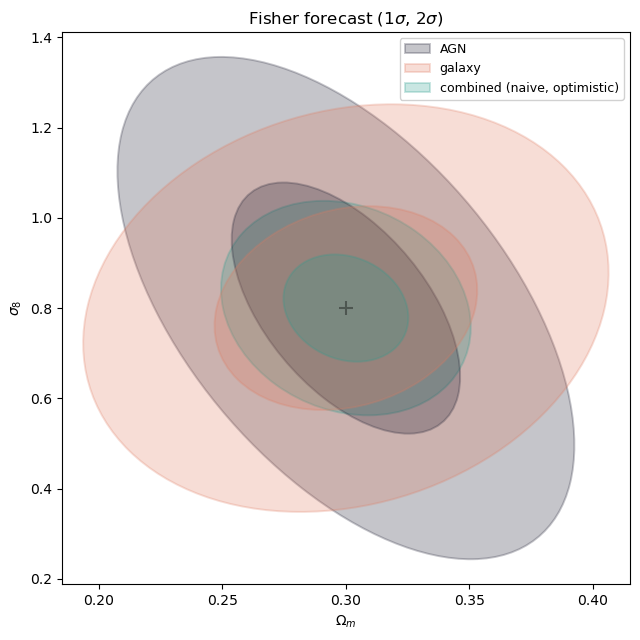

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
center = (theta_all["Omega_m"].mean(), theta_all["sigma_8"].mean())

plot_fisher_ellipse(ax, center, sub_agn, color="#1a1a2e", label="AGN")
plot_fisher_ellipse(ax, center, sub_gal, color="#e07a5f", label="galaxy")
plot_fisher_ellipse(ax, center, sub_combined, color="#2a9d8f", label="combined (naive, optimistic)")

ax.plot(*center, marker="+", color="0.2", ms=10, mew=1.5)
ax.set_xlabel(r"$\Omega_m$")
ax.set_ylabel(r"$\sigma_8$")
ax.set_title("Fisher forecast (1$\sigma$, 2$\sigma$)")
ax.legend(fontsize=9, framealpha=0.9)
ax.set_aspect("auto")
fig.tight_layout()


## 7. How much does combining actually help?

The 1-sigma ellipse's area is a single number summarizing the *joint*
`(Omega_m, sigma_8)` constraint (accounts for the parameter correlation,
not just each one's own marginal error).


In [9]:
def ellipse_area(cov2x2):
    return np.pi * np.sqrt(np.linalg.det(cov2x2))

area_agn, area_gal, area_combined = ellipse_area(sub_agn), ellipse_area(sub_gal), ellipse_area(sub_combined)
best_single_area = min(area_agn, area_gal)

print(f"1-sigma ellipse area -- AGN: {area_agn:.3e}, galaxy: {area_gal:.3e}, combined: {area_combined:.3e}")
print(f"combined area / best single-tracer area: {area_combined / best_single_area:.3f}  "
      f"({'smaller = tighter' if area_combined < best_single_area else 'not tighter than the best single tracer'})")

best_sigma_om = min(np.sqrt(sub_agn[0, 0]), np.sqrt(sub_gal[0, 0]))
best_sigma_s8 = min(np.sqrt(sub_agn[1, 1]), np.sqrt(sub_gal[1, 1]))
print(f"sigma(Omega_m): best single tracer -> combined, {best_sigma_om / np.sqrt(sub_combined[0, 0]):.2f}x tighter")
print(f"sigma(sigma_8): best single tracer -> combined, {best_sigma_s8 / np.sqrt(sub_combined[1, 1]):.2f}x tighter")


1-sigma ellipse area -- AGN: 3.390e-02, galaxy: 3.718e-02, combined: 9.290e-03
combined area / best single-tracer area: 0.274  (smaller = tighter)
sigma(Omega_m): best single tracer -> combined, 1.83x tighter
sigma(sigma_8): best single tracer -> combined, 1.90x tighter


## Reading this

- **AGN vs. galaxy ellipses**: galaxies should show a visibly tighter
  `sigma_8` axis than AGN (notebook 06 found `sigma_8` significant for
  galaxies, null for AGN) — if the ellipses instead look similar on that
  axis, the diagonal-covariance simplification or the linear-response
  approximation may be washing out a real difference, worth a second
  look before trusting the combined numbers below it.
- **The combined ellipse is an upper bound on how much combining helps,
  not a rigorous forecast.** `combine_fisher` assumes AGN and galaxies
  are independent given the parameters; they measurably aren't (median
  cross-tracer correlation 0.69, notebook 06). The true combined
  constraint is somewhere between "no better than the best single
  tracer" and what's plotted here — this notebook can bound it from
  above, not pin it down. A rigorous version needs the AGN-galaxy
  cross-covariance: running *both* tracers over the *same* CV
  realizations and measuring their joint scatter, not just each one's
  own.
- **This is a precision forecast, not a measurement.** It says how
  tightly `(Omega_m, sigma_8)` *could* be constrained from this
  statistic, under a local-linear, Gaussian-diagonal-noise
  approximation — not what their values actually are for any specific
  simulation or observation. Turning a *measured* kNN-CDF into point
  estimates of `Omega_m`/`sigma_8` needs a different tool: a
  regression/emulator trained on the LH suite (predict `(Omega_m,
  sigma_8)` from a summary vector, validated on a held-out split) — a
  separate, not-yet-built piece of the roadmap that this Fisher analysis
  motivates but doesn't replace.
- **The diagonal-covariance simplification (this module's docstring)
  likely makes every sigma here too small** — real bin-to-bin
  correlation in a smooth CDF would only add more uncertainty. Read
  every number in section 5/7 as optimistic.
